# Statistics for Comparison

In [11]:
import os
import pandas as pd
import numpy as np
from scipy.stats import skew, kurtosis, wasserstein_distance
from scipy.spatial.distance import jensenshannon
from sklearn.metrics.pairwise import rbf_kernel


def debug(msg):
    print(msg)


def compute_marginal_metrics(
    real_flat, synth_flat, bins=200, min_val=-4.0, max_val=4.0
):
    w_distance = wasserstein_distance(real_flat, synth_flat)
    hist_edges = np.linspace(min_val, max_val, bins + 1)
    real_hist, _ = np.histogram(real_flat, bins=hist_edges, density=False)
    synth_hist, _ = np.histogram(synth_flat, bins=hist_edges, density=False)
    epsilon = 1e-10
    real_prob = (real_hist + epsilon) / np.sum(real_hist + epsilon)
    synth_prob = (synth_hist + epsilon) / np.sum(synth_hist + epsilon)
    js_distance = jensenshannon(real_prob, synth_prob)
    return w_distance, js_distance


def compute_mmd(real_features, synth_features, gamma=None):
    if len(real_features) == 0 or len(synth_features) == 0:
        return np.nan
    XX = rbf_kernel(real_features, real_features, gamma=gamma)
    YY = rbf_kernel(synth_features, synth_features, gamma=gamma)
    XY = rbf_kernel(real_features, synth_features, gamma=gamma)
    mmd_squared = XX.mean() + YY.mean() - 2 * XY.mean()
    return np.sqrt(max(mmd_squared, 0))


df_real = pd.read_csv("../data/03_primary/dataset_splitted.csv")
df_real = df_real[df_real["split"] == "test"]
RUN_NAMES = [
    domain_shift_op + "_" + anomaly_label
    for anomaly_label, domain_shift_op in df_real[["anomaly_label", "domain_shift_op"]]
    .drop_duplicates()
    .values
]
REAL_PATH = "../data/03_primary/time_series_data/test"
OUTPUT_BASE_DIR = "../data/07_model_output"
axes = ["A_x [g]", "A_y [g]", "A_z [g]"]

records = []
total_runs = len(RUN_NAMES)

debug("Starting evaluation process...")

for i, run in enumerate(RUN_NAMES, start=1):
    debug("=" * 80)
    debug(f"Checking {i}/{total_runs} runs: {run}")

    tmp = run.split("_")
    speed = tmp[0]
    label = tmp[1]
    comb = f"{speed}_{label}"

    obs = df_real[
        (df_real["anomaly_label"] == label) & (df_real["domain_shift_op"] == speed)
    ]

    real_raw = {axis: [] for axis in axes}
    real_feat = {axis: [] for axis in axes}

    for file in obs.ism330dhcx_acc:
        file_path = os.path.join(REAL_PATH, file)
        ts = pd.read_parquet(file_path)
        ts = ts.iloc[1:].reset_index(drop=True).iloc[:37100]

        for axis in axes:
            vals = ts[axis].values
            real_raw[axis].extend(vals)
            real_feat[axis].append(
                [np.mean(vals), np.var(vals), skew(vals), kurtosis(vals)]
            )

    for axis in axes:
        real_raw[axis] = np.array(real_raw[axis])
        real_feat[axis] = np.array(real_feat[axis])

    synth_path = os.path.join(OUTPUT_BASE_DIR, f"synthetic_data_{run}.npy")

    if not os.path.exists(synth_path):
        debug(f"     File not found, skipping: {synth_path}")
        continue

    np_data = np.load(synth_path)
    num_samples = np_data.shape[0]

    synth_raw = {axis: [] for axis in axes}
    synth_feat = {axis: [] for axis in axes}

    for sample_idx in range(num_samples):
        for ax_idx, axis in enumerate(axes):
            vals = np_data[sample_idx, :, ax_idx]
            synth_raw[axis].extend(vals)
            synth_feat[axis].append(
                [np.mean(vals), np.var(vals), skew(vals), kurtosis(vals)]
            )

    for axis in axes:
        synth_raw[axis] = np.array(synth_raw[axis])
        synth_feat[axis] = np.array(synth_feat[axis])

    record = {"run": run}

    for axis in axes:
        ax_name = axis.split(" ")[0]
        if len(real_feat[axis]) > 0 and len(synth_feat[axis]) > 0:
            w_dist, js_dist = compute_marginal_metrics(real_raw[axis], synth_raw[axis])
            mmd_val = compute_mmd(real_feat[axis], synth_feat[axis])
        else:
            w_dist, js_dist, mmd_val = np.nan, np.nan, np.nan

        record[f"{ax_name}_W"] = w_dist
        record[f"{ax_name}_JS"] = js_dist
        record[f"{ax_name}_MMD"] = mmd_val

    records.append(record)

debug("=" * 80)
debug("Finished processing all runs.")
df_metrics = pd.DataFrame(records)
df_metrics.to_csv("../data/08_reporting/statistics.csv", index=False)

Starting evaluation process...
Checking 1/42 runs: spd1000_belt
Checking 2/42 runs: spd2000_normal
Checking 3/42 runs: spd1700_normal
Checking 4/42 runs: spd1200_normal
Checking 5/42 runs: spd2800_magnetic
Checking 6/42 runs: spd2400_belt
Checking 7/42 runs: spd1100_normal
Checking 8/42 runs: spd3000_normal
Checking 9/42 runs: spd1100_magnetic
Checking 10/42 runs: spd1400_magnetic
Checking 11/42 runs: spd1900_normal
Checking 12/42 runs: spd1300_normal
Checking 13/42 runs: spd1100_belt
Checking 14/42 runs: spd1800_magnetic
Checking 15/42 runs: spd1200_belt
Checking 16/42 runs: spd1900_magnetic
Checking 17/42 runs: spd1000_normal
Checking 18/42 runs: spd1600_normal
Checking 19/42 runs: spd1900_belt
Checking 20/42 runs: spd1500_magnetic
Checking 21/42 runs: spd1800_normal
Checking 22/42 runs: spd1300_belt
Checking 23/42 runs: spd2800_belt
Checking 24/42 runs: spd1400_normal
Checking 25/42 runs: spd1500_normal
Checking 26/42 runs: spd2400_magnetic
Checking 27/42 runs: spd1800_belt
Checking

In [12]:
df = pd.read_csv("../data/08_reporting/statistics.csv")
df.head()

,run,A_x_W,A_x_JS,A_x_MMD,A_y_W,A_y_JS,A_y_MMD,A_z_W,A_z_JS,A_z_MMD
0,spd1000_belt,0.018170,0.030462,0.216359,0.017116,0.028614,0.142729,0.013299,0.036044,0.160058
1,spd2000_normal,0.002069,0.009717,0.013816,0.008531,0.014964,0.034323,0.004869,0.010986,0.011727
2,spd1700_normal,0.004599,0.010647,0.041142,0.004281,0.010551,0.012417,0.004198,0.011146,0.040902
3,spd1200_normal,0.010836,0.022751,0.047984,0.002667,0.007452,0.005342,0.001593,0.009730,0.018335
4,spd2800_magnetic,0.005027,0.016966,0.051714,0.007762,0.013989,0.022363,0.004756,0.016376,0.074523


Generating Boxplots...


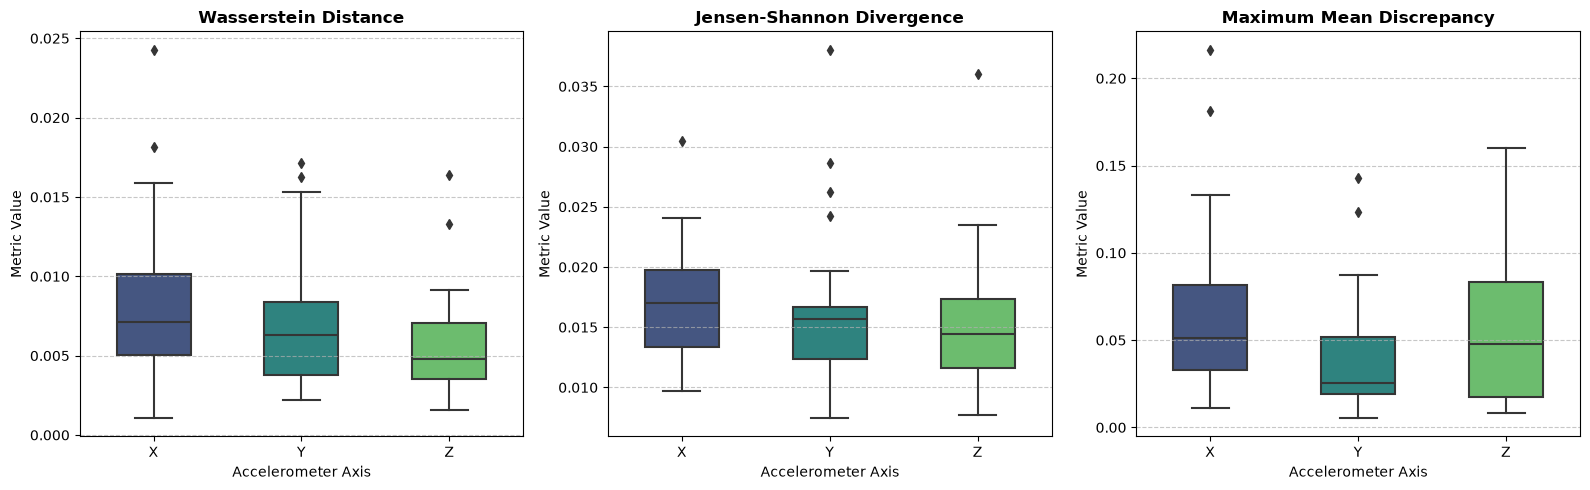

--------------------------------------------------
For Density Plots (Time Series / Histogram):
 -> Use run 'spd1800_normal' as your 'Best Case' (lowest divergence)
 -> Use run 'spd3000_belt' as your 'Worst Case' (highest divergence)
--------------------------------------------------

[POINT 3] Global Summary Table for the Dissertation:
|     | W               | JS              | MMD             |
|:----|:----------------|:----------------|:----------------|
| A_x | 0.0083 ± 0.0047 | 0.0169 ± 0.0044 | 0.0624 ± 0.0444 |
| A_y | 0.0070 ± 0.0039 | 0.0159 ± 0.0055 | 0.0390 ± 0.0315 |
| A_z | 0.0055 ± 0.0030 | 0.0152 ± 0.0050 | 0.0550 ± 0.0413 |

Note: Copy this table to the dissertation text to avoid reporting all 42 runs.

[POINT 4] Analysis by Domain:

--- Performance (Mean Wasserstein) by Speed ---
         A_x_W  A_y_W  A_z_W  Mean_Global_W
Speed                                      
spd1700 0.0070 0.0043 0.0035         0.0049
spd1200 0.0081 0.0033 0.0041         0.0052
spd1800 0.0060 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/08_reporting/statistics.csv")

print("Generating Boxplots...")

melted_df = pd.melt(
    df,
    id_vars=["run"],
    value_vars=[c for c in df.columns if c != "run"],
    var_name="Feature",
    value_name="Value",
)

melted_df["Axis"] = melted_df["Feature"].apply(lambda x: x.split("_")[1].upper())
melted_df["Metric"] = melted_df["Feature"].apply(lambda x: x.split("_")[2])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ["W", "JS", "MMD"]
titles = [
    "Wasserstein Distance",
    "Jensen-Shannon Divergence",
    "Maximum Mean Discrepancy",
]

for i, metric in enumerate(metrics):
    sns.boxplot(
        data=melted_df[melted_df["Metric"] == metric],
        x="Axis",
        y="Value",
        ax=axes[i],
        palette="viridis",
        width=0.5,
    )
    axes[i].set_title(titles[i], fontweight="bold")
    axes[i].set_xlabel("Accelerometer Axis")
    axes[i].set_ylabel("Metric Value")
    axes[i].grid(axis="y", linestyle="--", alpha=0.7)

plt.tight_layout()
plt.savefig("../data/08_reporting/boxplots_statistics.pdf", dpi=300)
plt.show()

df["Global_W_Score"] = df[["A_x_W", "A_y_W", "A_z_W"]].mean(axis=1)

best_run = df.loc[df["Global_W_Score"].idxmin(), "run"]
worst_run = df.loc[df["Global_W_Score"].idxmax(), "run"]

print("-" * 50)
print(f"For Density Plots (Time Series / Histogram):")
print(f" -> Use run '{best_run}' as your 'Best Case' (lowest divergence)")
print(f" -> Use run '{worst_run}' as your 'Worst Case' (highest divergence)")
print("-" * 50)

summary_df = pd.DataFrame(index=["A_x", "A_y", "A_z"], columns=["W", "JS", "MMD"])

for axis in ["A_x", "A_y", "A_z"]:
    for metric in ["W", "JS", "MMD"]:
        col = f"{axis}_{metric}"
        mean_val = df[col].mean()
        std_val = df[col].std()
        summary_df.loc[axis, metric] = f"{mean_val:.4f} ± {std_val:.4f}"

print("\n[POINT 3] Global Summary Table for the Dissertation:")
print(summary_df.to_markdown())
print(
    "\nNote: Copy this table to the dissertation text to avoid reporting all 42 runs."
)

df[["Speed", "Anomaly"]] = df["run"].str.split("_", n=1, expand=True)

print("\n[POINT 4] Analysis by Domain:")

speed_analysis = df.groupby("Speed")[["A_x_W", "A_y_W", "A_z_W"]].mean()
speed_analysis["Mean_Global_W"] = speed_analysis.mean(axis=1)
print("\n--- Performance (Mean Wasserstein) by Speed ---")
print(speed_analysis.sort_values(by="Mean_Global_W").to_string(float_format="%.4f"))

anomaly_analysis = df.groupby("Anomaly")[["A_x_W", "A_y_W", "A_z_W"]].mean()
anomaly_analysis["Mean_Global_W"] = anomaly_analysis.mean(axis=1)
print("\n--- Performance (Mean Wasserstein) by Anomaly Type ---")
print(anomaly_analysis.sort_values(by="Mean_Global_W").to_string(float_format="%.4f"))

Processing Best Case: spd1800_normal...


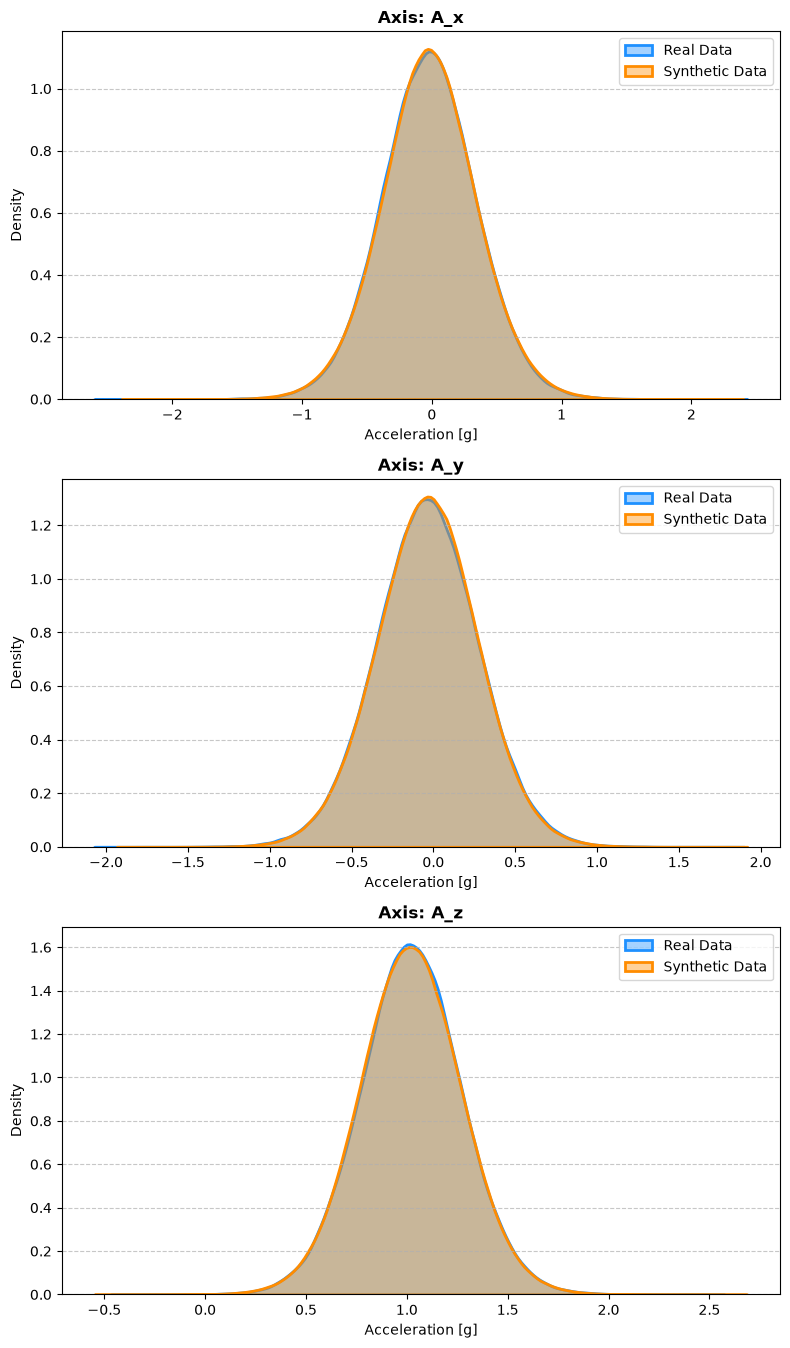

  -> Saved ../data/08_reporting/density_plot_spd1800_normal.pdf
Processing Worst Case: spd3000_belt...


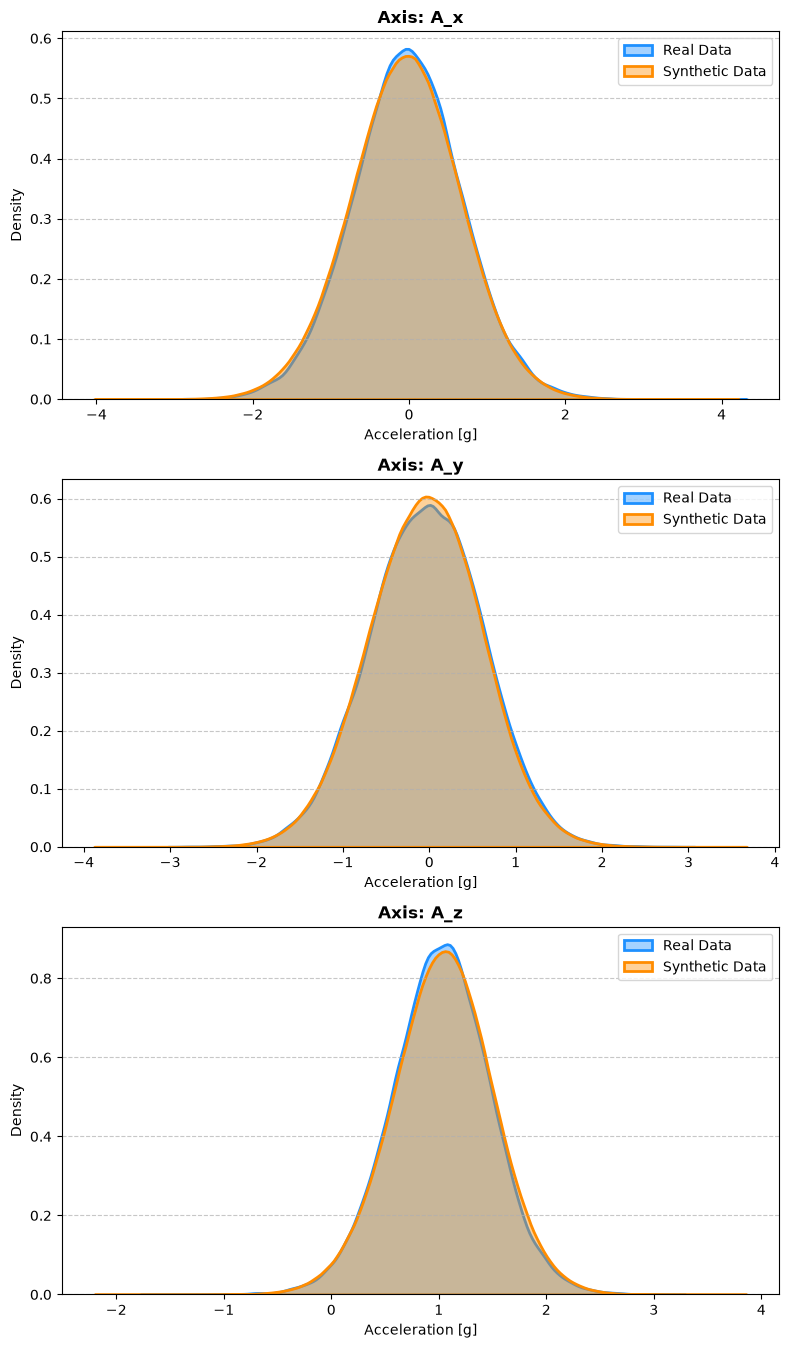

  -> Saved ../data/08_reporting/density_plot_spd3000_belt.pdf


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

REAL_CSV_PATH = "../data/03_primary/dataset_splitted.csv"
REAL_TS_DIR = "../data/03_primary/time_series_data/test"
SYNTH_BASE_DIR = "../data/07_model_output"
axes = ["A_x [g]", "A_y [g]", "A_z [g]"]

runs_to_plot = {"Best Case": "spd1800_normal", "Worst Case": "spd3000_belt"}

df_real = pd.read_csv(REAL_CSV_PATH)
df_real = df_real[df_real["split"] == "test"]

for case_name, run_name in runs_to_plot.items():
    print(f"Processing {case_name}: {run_name}...")

    tmp = run_name.split("_")
    speed = tmp[0]
    label = tmp[1]

    obs = df_real[
        (df_real["anomaly_label"] == label) & (df_real["domain_shift_op"] == speed)
    ]

    real_raw = {axis: [] for axis in axes}
    for file in obs.ism330dhcx_acc:
        file_path = os.path.join(REAL_TS_DIR, file)
        ts = pd.read_parquet(file_path)
        ts = ts.iloc[1:].reset_index(drop=True).iloc[:37100]
        for axis in axes:
            real_raw[axis].extend(ts[axis].values)

    synth_path = os.path.join(SYNTH_BASE_DIR, f"synthetic_data_{run_name}.npy")

    np_data = np.load(synth_path)

    synth_raw = {axis: [] for axis in axes}
    for ax_idx, axis in enumerate(axes):
        synth_raw[axis] = np_data[:, :, ax_idx].flatten()

    fig, axes_subplots = plt.subplots(3, 1, figsize=(8, 14))

    for i, axis in enumerate(axes):
        ax = axes_subplots[i]

        sns.kdeplot(
            real_raw[axis],
            ax=ax,
            label="Real Data",
            color="dodgerblue",
            fill=True,
            alpha=0.4,
            linewidth=2,
        )

        sns.kdeplot(
            synth_raw[axis],
            ax=ax,
            label="Synthetic Data",
            color="darkorange",
            fill=True,
            alpha=0.4,
            linewidth=2,
        )

        ax.set_title(f"Axis: {axis.split(' ')[0]}", fontweight="bold")
        ax.set_xlabel("Acceleration [g]")
        ax.set_ylabel("Density")
        ax.legend(loc="upper right")
        ax.grid(axis="y", linestyle="--", alpha=0.7)

    plt.tight_layout(rect=[0, 0, 1, 0.97])
    output_filename = f"../data/08_reporting/density_plot_{run_name}.pdf"
    plt.savefig(output_filename, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"  -> Saved {output_filename}")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler


def analyze_3d_point_distribution(
    real_data, fake_data, speed, condition, max_samples=5000
):
    """
    Flattens the time steps and analyzes if the generator learned the joint phase space
    of the 3 variables using t-SNE. Data is standardized prior to reduction.
    """
    # flatten to shape (total_steps, 3)
    real_points = real_data.reshape(-1, 3)
    fake_points = fake_data.reshape(-1, 3)

    # random sub-sampling for t-SNE (t-SNE with >5000 points is very slow)
    np.random.seed(42)
    idx_real = np.random.choice(
        real_points.shape[0], min(max_samples, real_points.shape[0]), replace=False
    )
    idx_fake = np.random.choice(
        fake_points.shape[0], min(max_samples, fake_points.shape[0]), replace=False
    )

    real_sample = real_points[idx_real]
    fake_sample = fake_points[idx_fake]

    X = np.vstack([real_sample, fake_sample])
    y = np.array([0] * len(real_sample) + [1] * len(fake_sample))

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    tsne = TSNE(n_components=2, perplexity=30, random_state=42)
    X_tsne = tsne.fit_transform(X_scaled)

    plt.figure(figsize=(10, 8))

    plt.scatter(
        X_tsne[y == 0, 0],
        X_tsne[y == 0, 1],
        label="Real",
        alpha=0.3,
        color="blue",
        s=10,
    )
    plt.scatter(
        X_tsne[y == 1, 0],
        X_tsne[y == 1, 1],
        label="Synthetic",
        alpha=0.3,
        color="red",
        s=10,
    )

    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"../data/08_reporting/tsne_{speed}_{condition}.pdf")
    plt.show()

In [17]:
df_splitted = catalog.load("training.df_splitted")
real_ts_spd1800_normal = df_splitted[
    (df_splitted["anomaly_label"] == "normal")
    & (df_splitted["domain_shift_op"] == "spd1800")
].iloc[0, -3]
real_ts_spd3000_belt = df_splitted[
    (df_splitted["anomaly_label"] == "belt")
    & (df_splitted["domain_shift_op"] == "spd3000")
].iloc[0, -3]

real_ts_spd1800_normal = pd.read_parquet(
    f"../data/03_primary/time_series_data/test/{real_ts_spd1800_normal}"
).values[1:37101, 1:]
real_ts_spd3000_belt = pd.read_parquet(
    f"../data/03_primary/time_series_data/test/{real_ts_spd3000_belt}"
).values[1:37101, 1:]

syn_ts_spd1800_normal = np.load(
    "../data/07_model_output/synthetic_data_spd1800_normal.npy"
)[0]
syn_ts_spd3000_belt = np.load(
    "../data/07_model_output/synthetic_data_spd3000_belt.npy"
)[0]

[09/23/26 01:17:32] INFO     Loading data from training.df_splitted (CSVDataset)...            ]8;id=212056;file://C:\Users\tmdp1\masters-dissertation-data-science\.venv\Lib\site-packages\kedro\io\data_catalog.py\data_catalog.py]8;;\:]8;id=212057;file://C:\Users\tmdp1\masters-dissertation-data-science\.venv\Lib\site-packages\kedro\io\data_catalog.py#1050\1050]8;;\

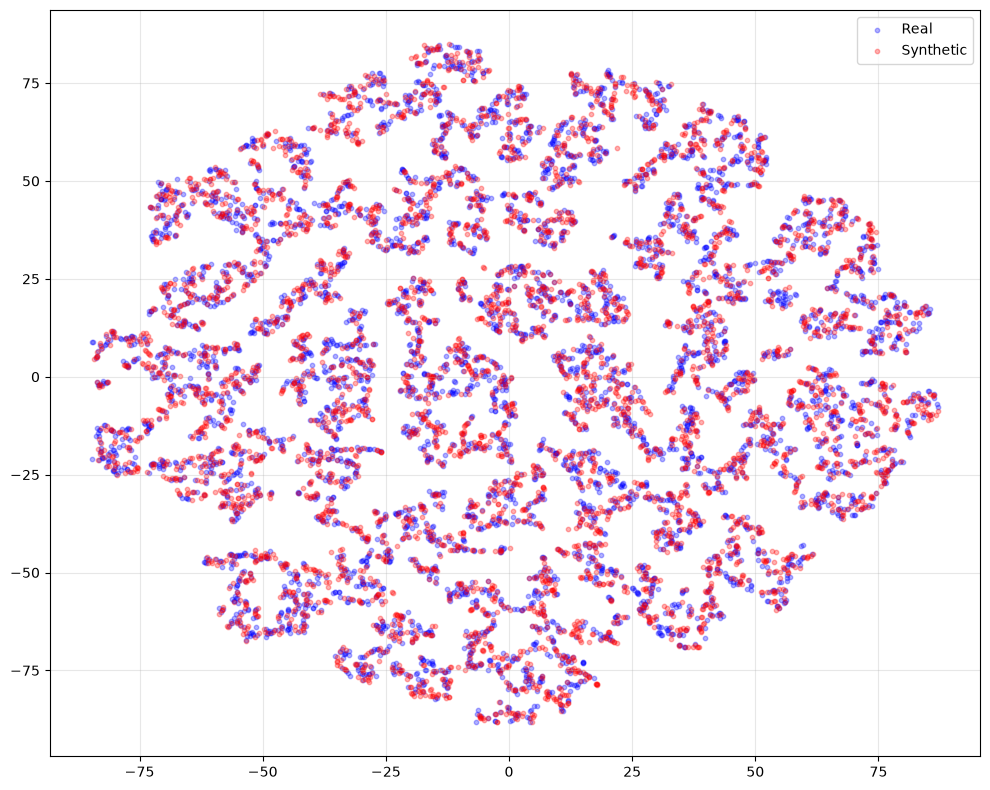

In [18]:
analyze_3d_point_distribution(
    real_ts_spd1800_normal, syn_ts_spd1800_normal, "spd1800", "normal"
)

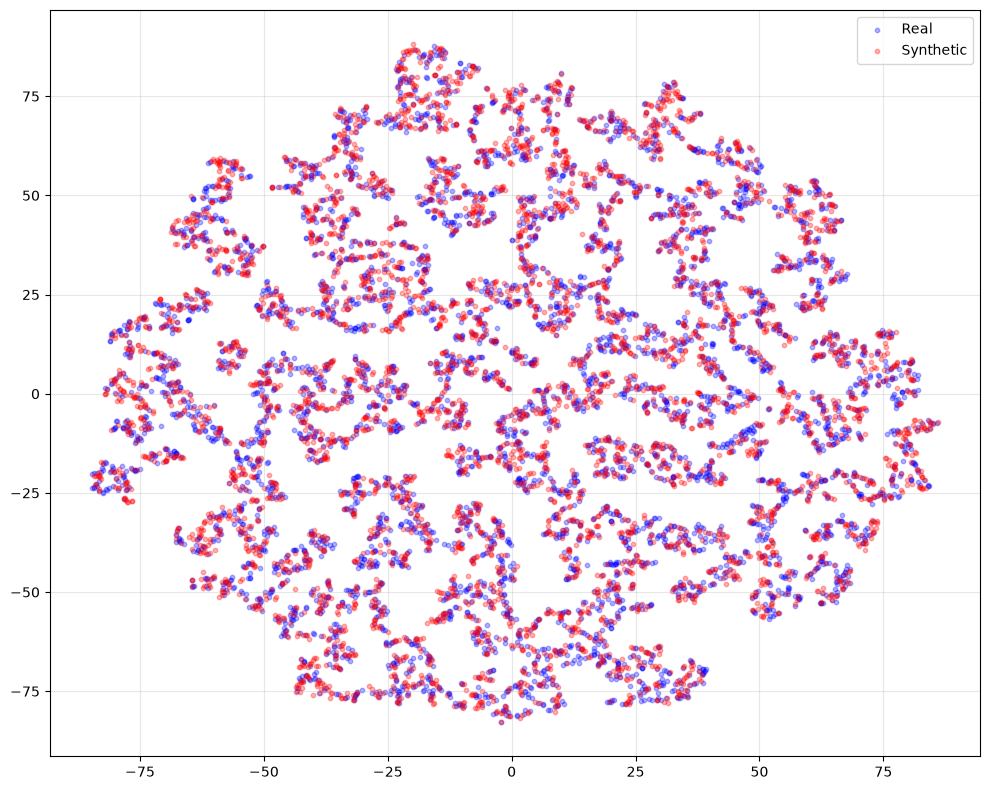

In [19]:
analyze_3d_point_distribution(
    real_ts_spd3000_belt, syn_ts_spd3000_belt, "spd3000", "belt"
)